In [1]:
import numpy as np
import torch
from torch import linalg
import numpy as np
from scipy.stats import norm, uniform
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
rng = torch.manual_seed(10404)

In [2]:

def torch_random_orthog(n_dim, batch_shape=None, random_state=None):
    size = (n_dim, n_dim)
    if batch_shape is not None:
        size = tuple(batch_shape) + size

    if random_state is not None:
        gen = torch.Generator()
        gen.manual_seed(random_state)
        a = torch.randn(size=size, generator=gen)
    else:
        a = torch.randn(size=size)

    Q, R = torch.linalg.qr(a)
    return Q

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq


def random_covariance(dim, variances, sigma=1.0):
    A = np.random.normal(0, sigma, size=(dim, dim))
    M = A @ A.T

    
    return M

def random_covariance_batch(batch_size, dim, sigma = 1.0):
    A = rng.normal(0,sigma,size = (batch_size, dim,dim))
    return A @ np.transpose(A,(0,2,1))
def batched_mixture(x,sigmas,weights):
    cdfs = norm.cdf(x,loc = 0, scale = sigmas)
    return(cdfs*weights[None,:]).sum(axis =1)

def make_mixture_covariances(dim, variances, K, sigma=1.0):
    """
    Build K covariance matrices Sigma_k, each with the same prescribed diagonal.
    """
    return [random_covariance(dim, variances, sigma=sigma) for _ in range(K)]


def sample_row_mixture(m, covariances, weights=None):
    """
    Sample an m x n matrix A whose rows are drawn from a Gaussian mixture:
        row ~ sum_k w_k N(0, Sigma_k)
    """
    K = len(covariances)
    n = covariances[0].shape[0]

    if weights is None:
        weights = np.ones(K) / K
    weights = np.asarray(weights)
    weights = weights / weights.sum()

    comps = np.random.choice(K, size=m, p=weights)
    A = np.zeros((m, n))

    for i, k in enumerate(comps):
        A[i] = np.random.multivariate_normal(mean=np.zeros(n), cov=covariances[k])

    return A, comps


def sample_covariance_matrix(A, normalize=True):
    S = A.T @ A
    if normalize:
        S = S / A.shape[0]
    return S


def mixture_upper_tail(x, sigmas, weights=None):
    """
    P(X > x) for X ~ sum_k w_k N(0, sigmas[k]^2)
    """
    sigmas = np.asarray(sigmas)
    K = len(sigmas)

    if weights is None:
        weights = np.ones(K) / K
    weights = np.asarray(weights)
    weights = weights / weights.sum()

    return np.sum(weights * (1.0 - norm.cdf(x / sigmas)))


def mixture_two_sided_tail(x, sigmas, weights=None):
    """
    P(|X| > x) for X ~ sum_k w_k N(0, sigmas[k]^2)
    """
    sigmas = np.asarray(sigmas)
    K = len(sigmas)

    if weights is None:
        weights = np.ones(K) / K
    weights = np.asarray(weights)
    weights = weights / weights.sum()

    return np.sum(weights * 2.0 * (1.0 - norm.cdf(x / sigmas)))


def epsilon_point(sigmas, epsilon=1e-3, weights=None, two_sided=True):
    """
    Solve for x such that:
        P(|X| > x) = epsilon   if two_sided=True
        P(X > x)  = epsilon    if two_sided=False
    where X is a Gaussian mixture with component std devs = sigmas.
    """
    sigmas = np.asarray(sigmas)

    if weights is None:
        weights = np.ones(len(sigmas)) / len(sigmas)

    tail_fn = mixture_two_sided_tail if two_sided else mixture_upper_tail

    def f(x):
        return tail_fn(x, sigmas, weights) - epsilon

    lo = 0.0
    hi = 10.0 * np.max(sigmas)

    while f(hi) > 0:
        hi *= 2.0

    return brentq(f, lo, hi)


def epsilon_points_all_coordinates(covariances, epsilon=1e-3, weights=None, two_sided=True):
    """
    For each coordinate j, compute epsilon point from the mixture marginal:
        X_j ~ sum_k w_k N(0, (Sigma_k)_{jj})
    """
    K = len(covariances)
    n = covariances[0].shape[0]

    if weights is None:
        weights = np.ones(K) / K
    weights = np.asarray(weights)
    weights = weights / weights.sum()

    xeps = np.zeros(n)

    for j in range(n):
        variances_j = np.array([Sigma[j, j] for Sigma in covariances])
        sigmas_j = np.sqrt(variances_j)
        xeps[j] = epsilon_point(sigmas_j, epsilon=epsilon, weights=weights, two_sided=two_sided)

    return xeps


# --------------------------------------------------
# Example
# --------------------------------------------------
if __name__ == "__main__":
    np.random.seed(0)

    dim = 4
    variances = [1, 2, 3, 4]
    K = 5
    m = 2000

    # Build K covariance matrices for the Gaussian mixture
    covariances = make_mixture_covariances(dim, variances, K, sigma=1.0)

    print("Example covariance matrix:")
    print(covariances[0])
    print("Diagonal:")
    print(np.diag(covariances[0]))

    # Sample matrix A from row-wise Gaussian mixture
    A, comps = sample_row_mixture(m, covariances)

    S = sample_covariance_matrix(A, normalize=True)

    print("\nSample covariance matrix:")
    print(S)

    print("\nSample covariance diagonal:")
    print(np.diag(S))

    # Epsilon points
    eps = 1e-3
    xeps = epsilon_points_all_coordinates(covariances, epsilon=eps, two_sided=True)

    print(f"\nTwo-sided epsilon points for epsilon={eps}:")
    print(xeps)


In [10]:
def torch_dialect_arrays(n_dialect, batch_shape, random_state=None, eval_range=torch.tensor([.5,1.5])):
    U = torch_random_orthog(n_dialect, batch_shape=batch_shape, random_state=random_state)
    eval_scale = eval_range[1] - eval_range[0]
    d = eval_range[0] + eval_scale * torch.rand(size=tuple(batch_shape)+(n_dialect,))
    return U, d



In [49]:
def sample_from_dialects(nsamp,O_c,d_c,d,U):
    n_common = d_c.shape[-1]
    n_dialect = d.shape[-1]
    batch_shape = d.shape[:-1]

    z_common = torch.randn(size = batch_shape+(nsamp,n_common))
    z_common = z_common *torch.sqrt(d_c)

    eps = torch.randn(size = batch_shape + (nsamp,n_dialect))
    z_dialect = eps * torch.sqrt(d[...,None,:])
    Ut_z = (U.mT[...,None,:,:] @ z_dialect.unsqueeze(-1)).squeeze(-1)
    O_common = O_c[:,: n_common]
    O_dialect = O_c[:, n_common:]
    x_common = (z_common.unsqueeze(-2)@ O_common.mT).squeeze(-2)
    x_dialect = (Ut_z.unsqueeze(-2)@ O_dialect.mT).squeeze(-2)
    x_total = x_common+x_dialect
    return x_common, x_dialect,x_total

def array_cov(O_c, d_c,d,U):
    n_common = d_c.shape[-1]
    O_common = O_c[:,:n_common]
    O_dialect = O_c[:,n_common:]
    cov_common = O_common @ torch.diag(d_c)@ O_common.mT
    D = torch.diag_embed(d)
    UDU = U.mT @ D @ U
    cov_dialect = O_dialect @ UDU @ O_dialect.mT
    cov_total = cov_common + cov_dialect
    return cov_total
def sampled_cov(sample):
    mean = sample.mean(dim = 1)
    centered = sample-mean.unsqueeze(-2)
    cov = centered.mT @ centered / (sample.shape[-2] -1)
    return cov



In [50]:
n_dialect = 4
n_context = 8
batch_shape = (10,)
nsamp = 10_000
U, d = torch_dialect_arrays(n_dialect, batch_shape) 
O_c = torch_random_orthog(n_context)
d_c = torch.tensor([.8, .9, 1.0, 1.1])
x_common, x_dialect, x_total = sample_from_dialects(nsamp, O_c, d_c, d, U)

In [52]:
common_10, dialect_10, total_10 = sample_from_dialects(nsamp,O_c,d_c,d,U)
dialects_sample = [dialect_10[i] for i in range(dialect_10.shape[0])]
common_sample = [common_10[i] for i in range(dialect_10.shape[0])]
dialect_pts = {i: dialect_10[i].numpy() for i in range(9)}
common_pts = {i:common_10[i].numpy() for i in range(9)}
dialect_df = pd.concat(
    [pd.DataFrame(dialect_pts[i], columns=[f"dim{j}" for j in range(8)]).assign(dialect=i) for i in range(9)],
    ignore_index=True)
common_df = pd.concat(
    [pd.DataFrame(common_pts[i], columns=[f"dim{j}" for j in range(8)]).assign(dialect=i) for i in range(9)],
    ignore_index=True)
dialect_df.tail(10)

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dialect
89990,1.016824,1.148084,-0.423962,-0.655349,-0.418681,-0.116131,-0.378443,-0.120828,8
89991,0.401446,0.378683,-0.738688,-0.301176,-0.302557,1.101987,0.077593,-0.273346,8
89992,-0.167430,0.382673,0.167670,0.262467,-0.001071,0.002656,-0.080962,-0.030953,8
89993,0.741780,1.908986,0.590668,-0.288535,-0.320206,-1.290265,-0.197809,0.093138,8
89994,-0.346225,-0.516357,-0.158611,0.438844,0.228812,0.022395,-0.979290,-0.021369,8
89995,-0.412808,0.783540,0.018574,0.396151,-0.186449,1.207642,0.898758,-0.247019,8
89996,0.067497,-1.039933,0.401199,-0.392219,0.231711,-1.083634,0.365449,0.337313,8
89997,0.553502,0.524486,0.362043,-0.293710,-0.019191,-1.462629,-0.722552,0.207806,8
89998,0.218316,1.625708,0.161817,-0.058354,-0.415890,0.568691,0.956153,-0.190081,8
89999,-1.341569,-1.980883,0.492966,0.656437,0.567100,0.328906,1.005881,0.192678,8


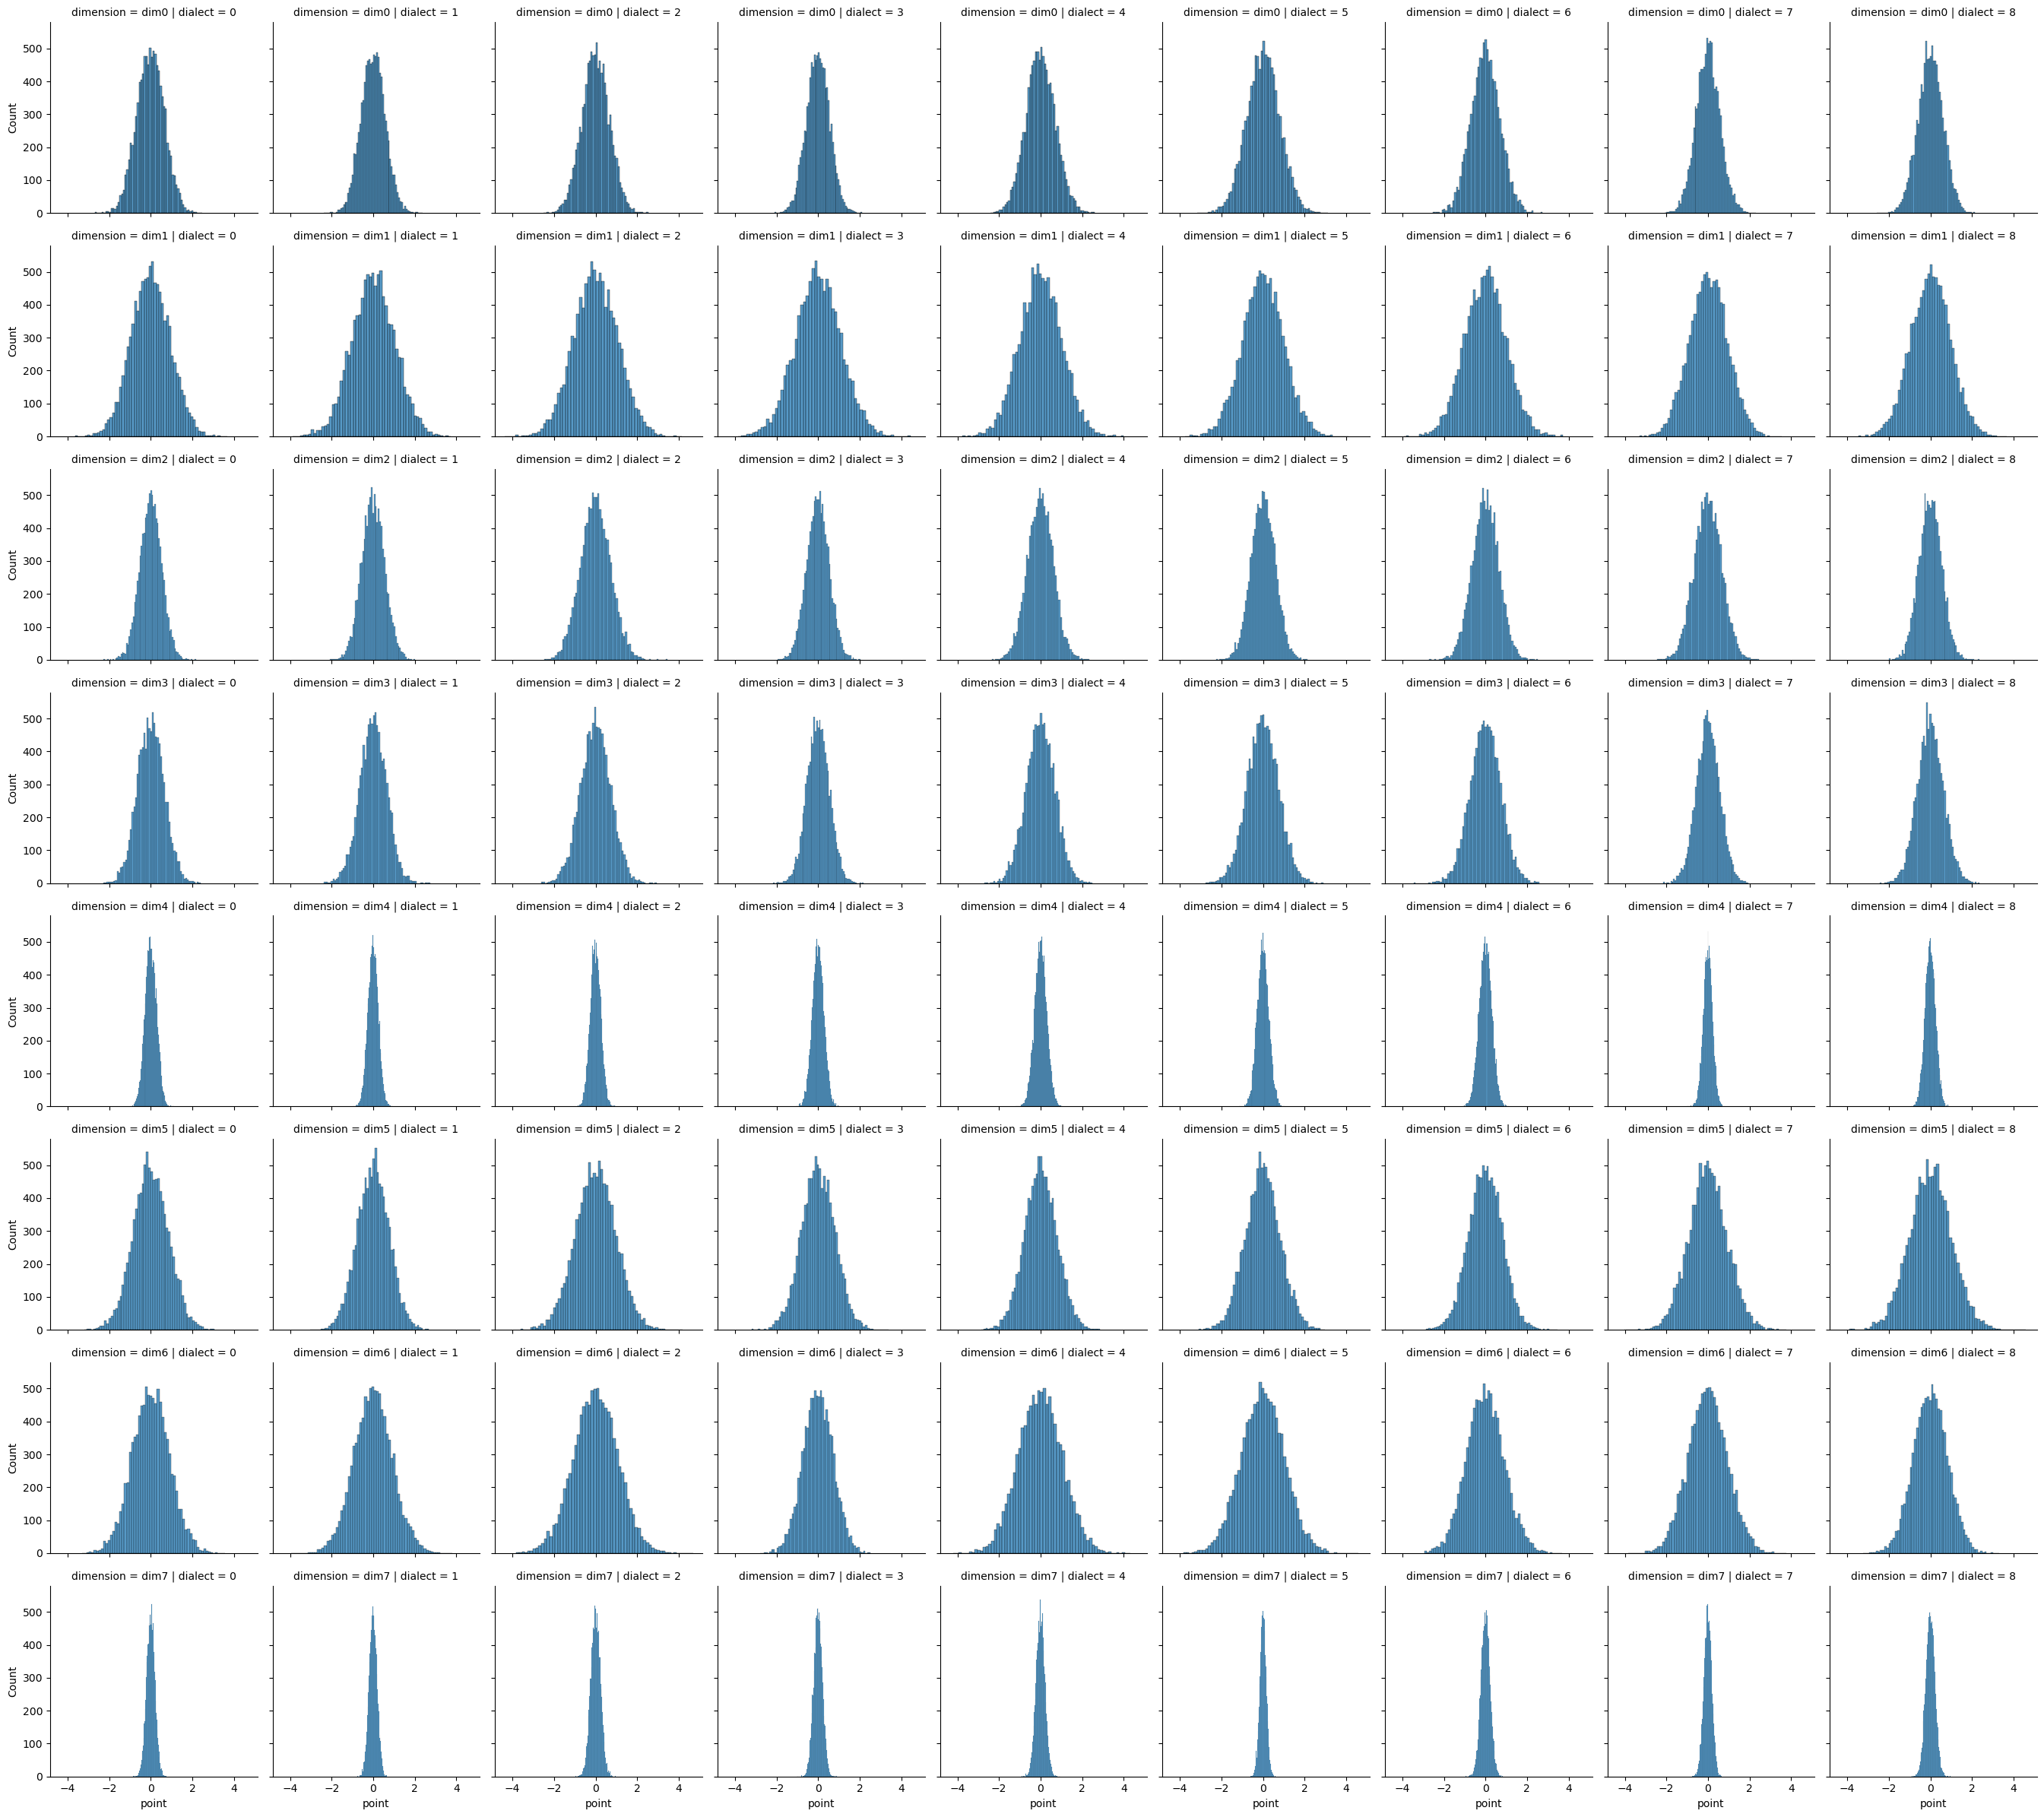

In [54]:
dialect_long = pd.melt(dialect_df, id_vars = ["dialect"],
                       value_vars = ["dim0","dim1","dim2","dim3","dim4","dim5","dim6","dim7"],
                       var_name = "dimension",
                       value_name = "point")
p = sns.FacetGrid(dialect_long,col = "dialect",row = "dimension")
p.map(sns.histplot,"point")
                                      

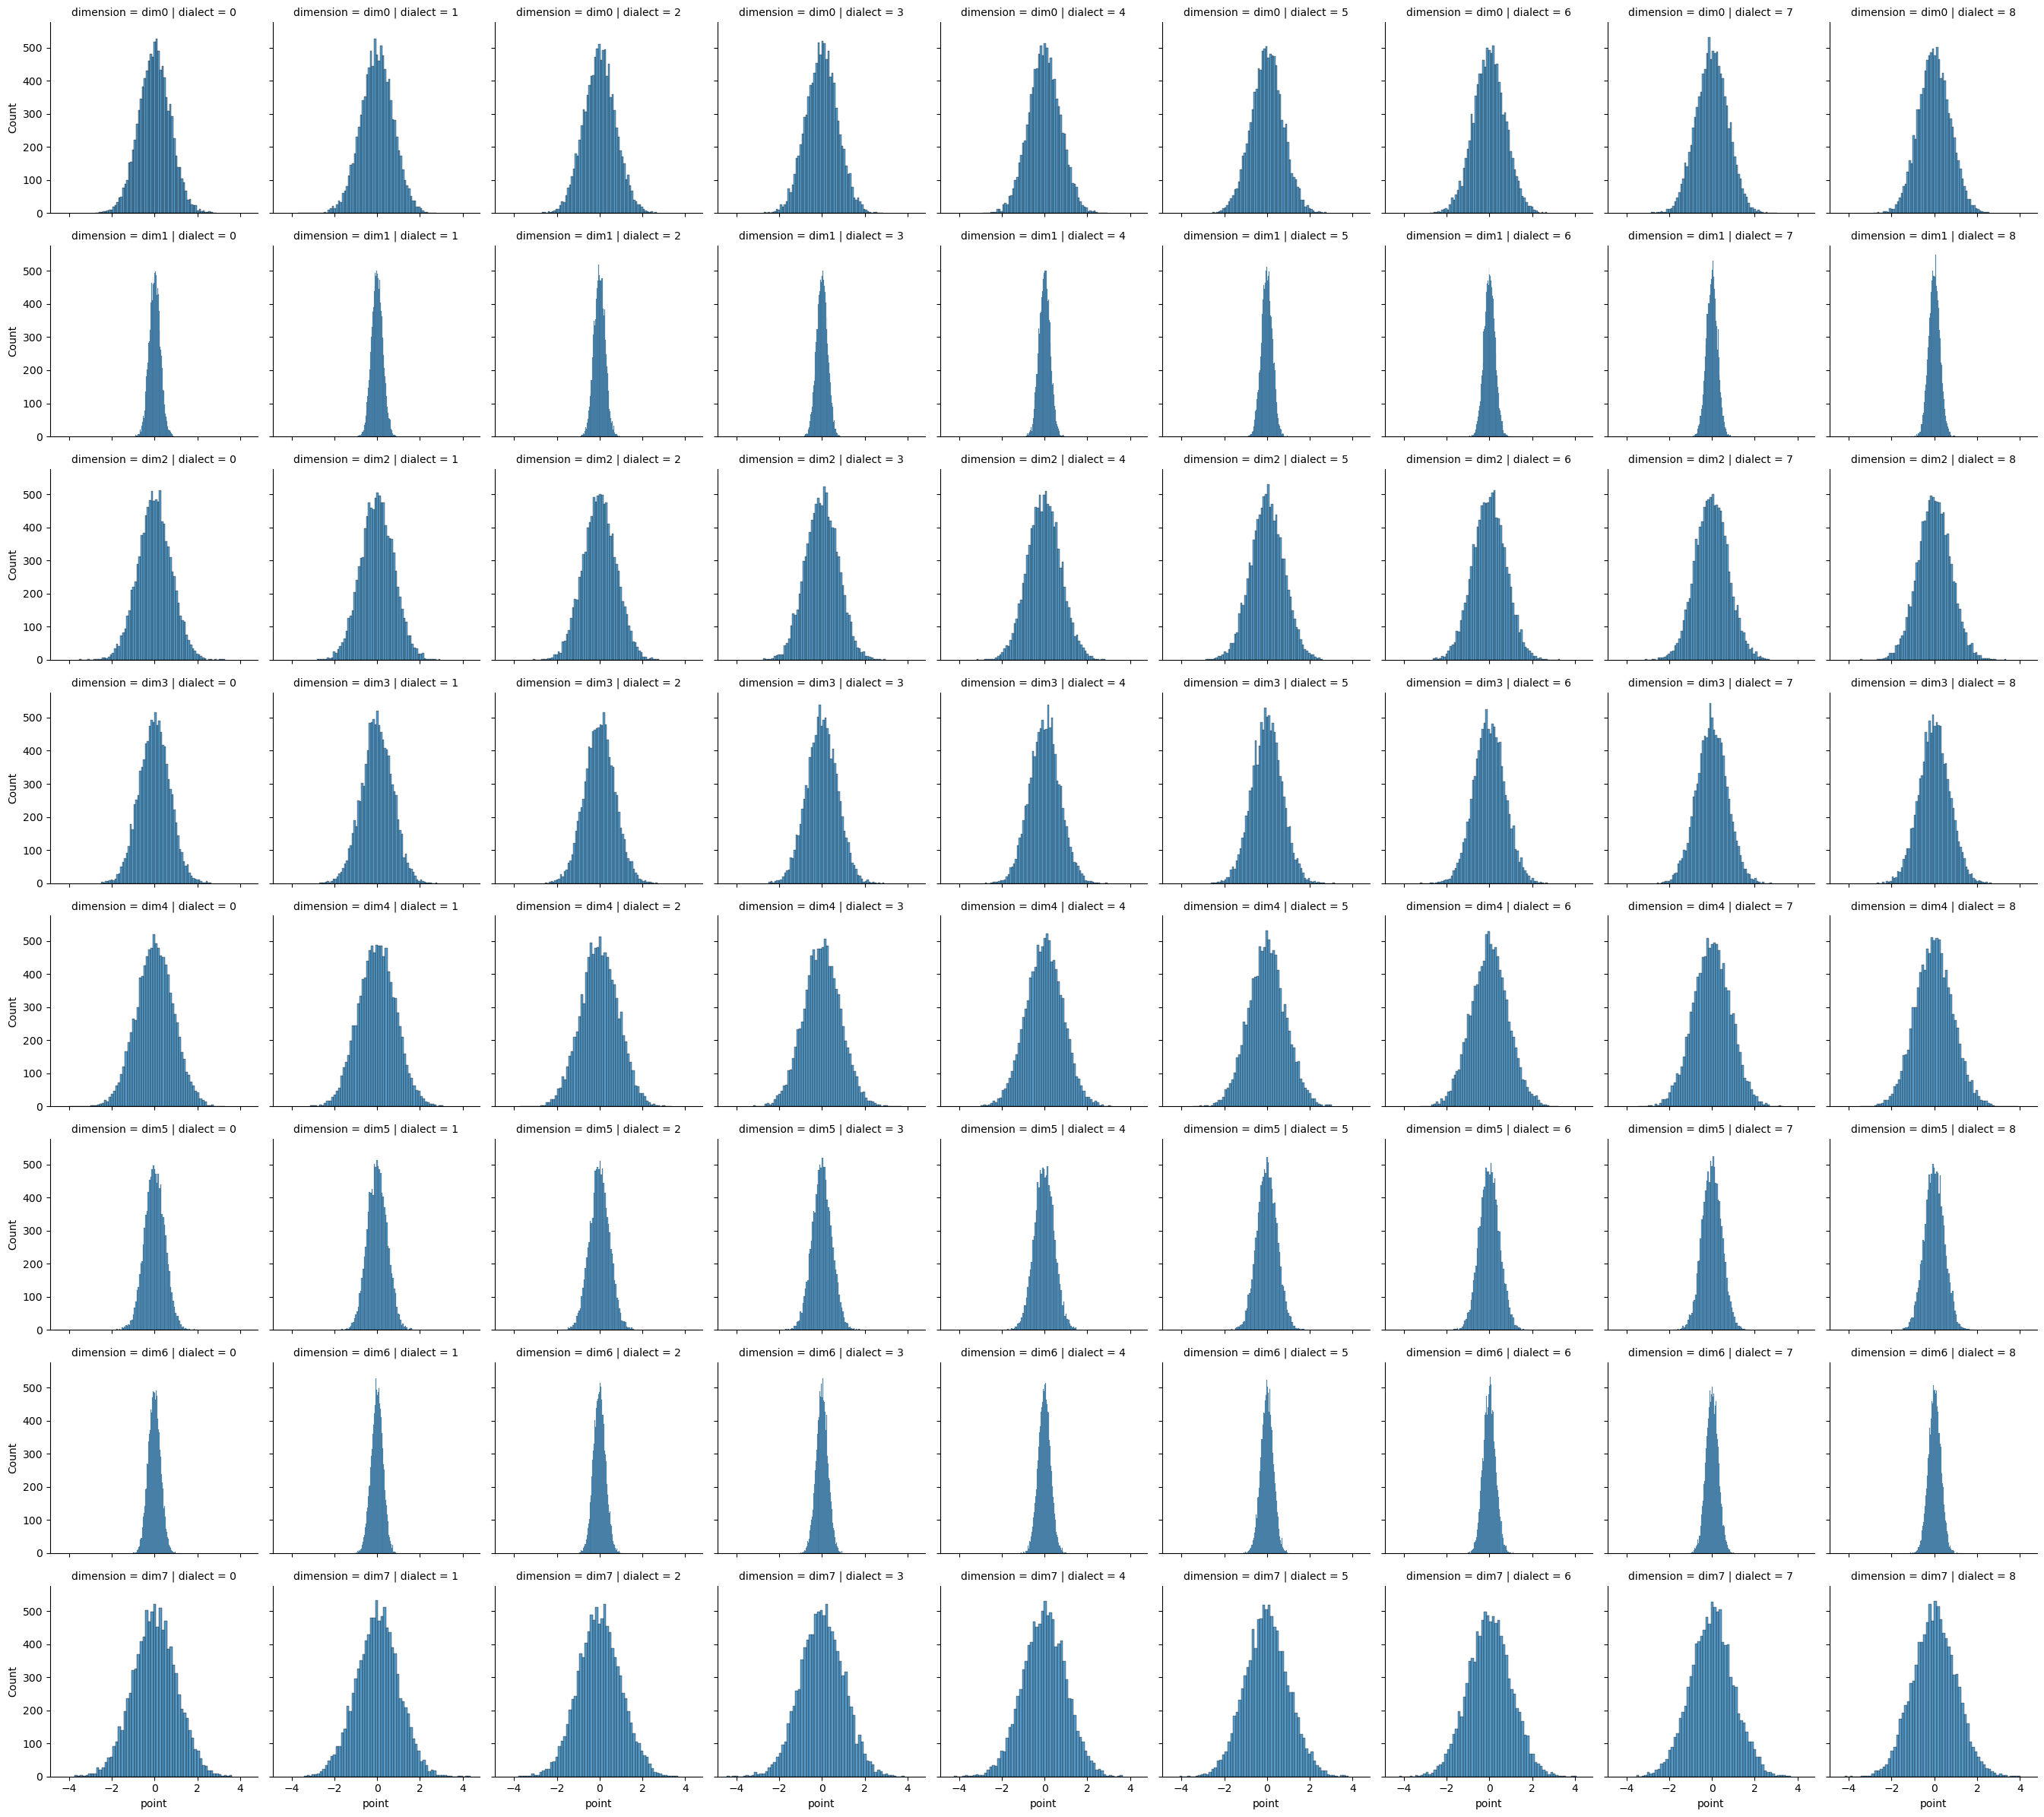

In [55]:
common_long = pd.melt(common_df, id_vars = ["dialect"],
                       value_vars = ["dim0","dim1","dim2","dim3","dim4","dim5","dim6","dim7"],
                       var_name = "dimension",
                       value_name = "point")
p = sns.FacetGrid(common_long,col = "dialect",row = "dimension")
p.map(sns.histplot,"point")

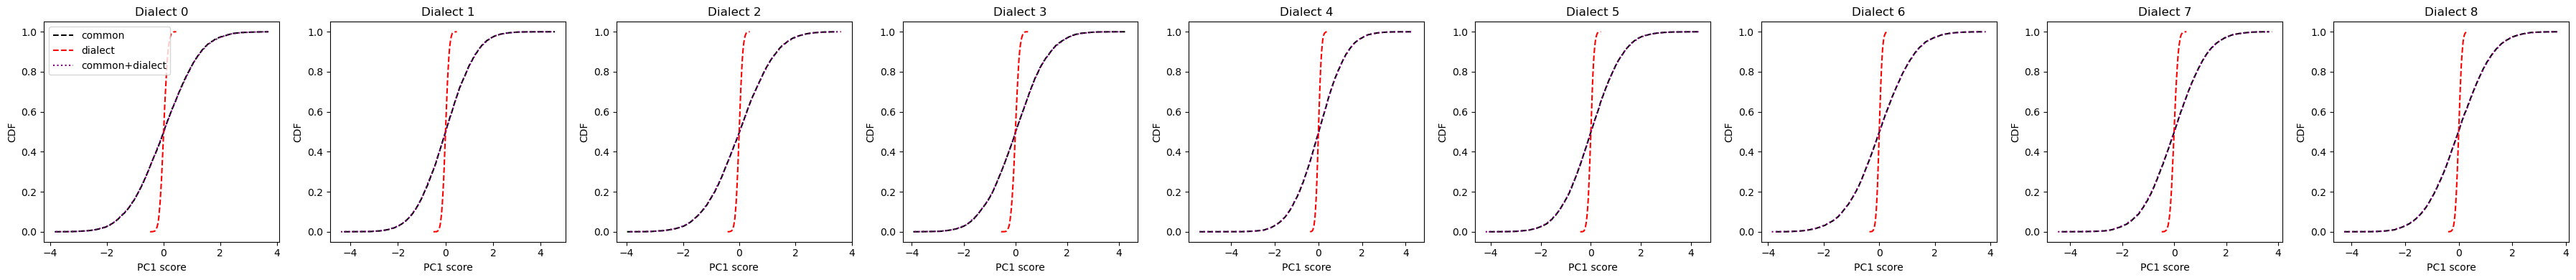

In [39]:
dialects_to_plot = range(9)
fig, axes = plt.subplots(1, len(dialects_to_plot), figsize=(4*len(dialects_to_plot), 4))

all_cumul = np.vstack([common_10[d].numpy() + dialect_10[d].numpy() for d in dialects_to_plot])
pca = PCA(n_components=6)
pca.fit(all_cumul)
W = pca.components_ 

for ax, dial in zip(axes, dialects_to_plot):
    common_vec  = common_10[dial].numpy()
    dialect_vec = dialect_10[dial].numpy()
    cumulative  = common_vec + dialect_vec

    pc1_common  = common_vec  @ W[0]
    pc1_dialect = dialect_vec @ W[0]
    pc1_cumul   = cumulative  @ W[0]

    p = np.linspace(0, 1, 10000)
    ax.plot(np.sort(pc1_common),  p, linestyle="--", color="black",  label="common")
    ax.plot(np.sort(pc1_dialect), p, linestyle="--", color="red",    label="dialect")
    ax.plot(np.sort(pc1_cumul),   p, linestyle=":",  color="purple",  label="common+dialect")
    ax.set_title(f"Dialect {dial}")
    ax.set_xlabel("PC1 score")
    ax.set_ylabel("CDF")

axes[0].legend()
plt.tight_layout()
plt.show()

In [57]:
print("U:", U.shape)
print("d:", d.shape)
print("O_c:", O_c.shape)
print("x_common:", x_common.shape)
print("x_dialect:", x_dialect.shape)
print("x_total:", x_total.shape)

U: torch.Size([10, 4, 4])
d: torch.Size([10, 4])
O_c: torch.Size([8, 8])
x_common: torch.Size([10, 10000, 8])
x_dialect: torch.Size([10, 10000, 8])
x_total: torch.Size([10, 10000, 8])


In [84]:
def sampler_PCA(x_dialect, n_components = 4):
    X = x_dialect.reshape(-1,x_dialect.shape[-1])
    mean = X.mean(dim = 0, keepdim = True)
    print(type(mean))
    X_centered = X-mean
    U_svd, S, Vh = torch.linalg.svd(X_centered, full_matrices= False)
    print(S.shape)
    
    comps = Vh[:n_components]
    X_reduced = X_centered @ comps.T
    var_explained = (S[:n_components]**2)/(S**2).sum()
    return X_reduced, var_explained, comps
dialect_reduced,dialect_ev, dialect_comps =  sampler_PCA(x_dialect)
common_reduced, common_ev, common_comps = sampler_PCA(x_common)


def fit_pca_torch(x, n=4):
    
    X = x.reshape(-1, x.shape[-1])
    mean = X.mean(dim=0, keepdim=True)
    Xc = X - mean

    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
    comps = Vh[:n]  

    var = (S ** 2) / (X.shape[0] - 1)
    explained = var[:n] / var.sum()

    return mean.squeeze(0), comps, explained

PCA_dialect, PCA_comps, PCA_explained = fit_pca_torch(x_dialect,n = 4)    
print(PCA_comps.shape)
def project_pca(x,mean,comps):
    x_centered = x- mean
    z = torch.einsum("...d,rd -> ...r",x_centered,comps)
    return z
z_dialect = project_pca(x_dialect, PCA_dialect, PCA_comps)
print(z_dialect.shape)


<class 'torch.Tensor'>
torch.Size([8])
<class 'torch.Tensor'>
torch.Size([8])
torch.Size([4, 8])
torch.Size([10, 10000, 4])


In [89]:
def make_axis_codebook_pca(r):
    I = torch.eye(r)
    codebook = torch.cat([I,-I],dim = 0)
    return codebook
codebook_pca = make_axis_codebook_pca(z_dialect.shape[-1])
print(codebook_pca.shape)
def survival_tokenizer(x,codebook, beta = 4, return_probs = True):
    scores = x @ codebook.T
    top = scores.max(dim =1, keepdim = True).values
    gaps = top-scores
    w = torch.exp(-beta *gaps)
    probs = w/w.sum(dim = 1, keepdim = True)
    flat_probs = probs.reshape(-1,probs.shape[-1])
    tokens = torch.multinomial(flat_probs,1).squeeze(-1).reshape(x.shape[:-1])
    if return_probs:
        return tokens, probs, scores, gaps
    return tokens

pca_tokens, pca_probs, pca_scores, pca_gaps = survival_tokenizer(z_dialect,codebook_pca )
print(pca_tokens.shape)

torch.Size([8, 4])
torch.Size([10, 10000])


In [90]:
print(pca_tokens)

tensor([[5, 2, 7,  ..., 4, 6, 0],
        [7, 1, 4,  ..., 5, 2, 7],
        [5, 7, 5,  ..., 0, 5, 3],
        ...,
        [5, 3, 2,  ..., 6, 1, 2],
        [7, 3, 3,  ..., 2, 1, 0],
        [3, 5, 3,  ..., 0, 7, 7]])
